# Seasonal Agriculture Performance Analysis

## Objective
This notebook analyzes a seasonal agriculture performance dataset covering **4,000 farm records** across **8 Indian states**, **8 crops**, and **3 cropping seasons** (Kharif, Rabi, Zaid). The goal is to explore, clean, and analyze the data to uncover meaningful seasonal patterns, trends, relationships, and differences in agricultural performance — and to translate those findings into evidence-based recommendations for seasonal agricultural planning.

## Contents
1. Dataset Overview & Import
2. Data Quality Assessment
3. Data Cleaning & Preparation
4. Feature Engineering
5. Exploratory Data Analysis — Environmental Conditions by Season
6. Yield Analysis Across Seasons & Crops
7. Economic Performance Analysis (Cost, Revenue, Profit)
8. Correlation Analysis
9. Crop × Season Profitability Deep-Dive
10. Resource Usage & Water-Use Efficiency
11. Disease & Pest Risk Patterns
12. State-wise Seasonal Performance
13. Key Insights
14. Recommendations
15. Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
PALETTE = {'Kharif': '#2E86AB', 'Rabi': '#4CAF50', 'Zaid': '#F5A623'}

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset Overview & Import

The dataset (`seasonal_agriculture_performance_dataset.csv`) contains farm-level records with environmental conditions (rainfall, temperature, humidity, sunlight, soil), farming inputs (fertilizer, pesticide, irrigation, seed quality), and outcomes (yield, production, cost, revenue, profit, water usage).

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 2. Data Quality Assessment

Before analysis, we check for missing values, duplicates, and any inconsistent or implausible values.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} out of {df.shape[0]*df.shape[1]} ({100*missing.sum()/(df.shape[0]*df.shape[1]):.3f}%)")

print(f"\nDuplicate Farm_ID entries: {df['Farm_ID'].duplicated().sum()}")
print(f"Fully duplicated rows: {df.duplicated().sum()}")

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 out of 112000 (0.107%)

Duplicate Farm_ID entries: 0
Fully duplicated rows: 0


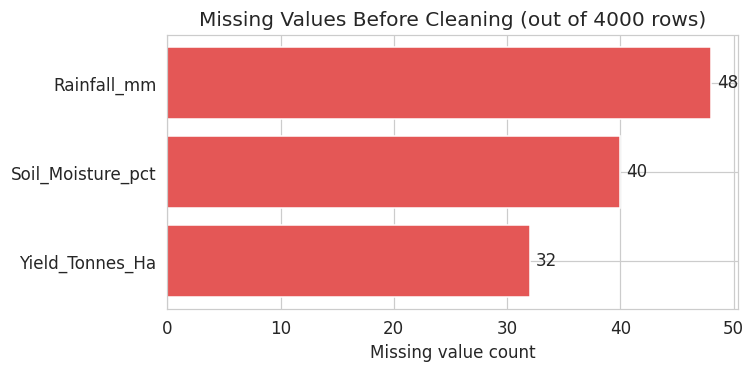

In [5]:
# Visualize missing values
miss_plot = df.isnull().sum()
miss_plot = miss_plot[miss_plot > 0].sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(miss_plot.index, miss_plot.values, color='#E45756')
ax.set_xlabel('Missing value count')
ax.set_title('Missing Values Before Cleaning (out of 4000 rows)')
for i, v in enumerate(miss_plot.values):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

In [6]:
# Check whether missingness is concentrated in any particular season (i.e. missing-at-random check)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    print(f"--- {col} missing, by Season ---")
    print(df[df[col].isnull()]['Season'].value_counts(), "\n")

--- Rainfall_mm missing, by Season ---
Season
Kharif    19
Rabi      18
Zaid      11
Name: count, dtype: int64 

--- Soil_Moisture_pct missing, by Season ---
Season
Kharif    18
Rabi      13
Zaid       9
Name: count, dtype: int64 

--- Yield_Tonnes_Ha missing, by Season ---
Season
Rabi      20
Kharif     7
Zaid       5
Name: count, dtype: int64 



**Observation:** Missing values are limited to three columns (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`) and together account for less than 0.1% of all cells. The missing records are spread proportionally across all three seasons, suggesting the values are missing at random rather than tied to a specific season — so a season-aware imputation is a safe and appropriate strategy.

We also check for implausible values — e.g. the maximum `Yield_Tonnes_Ha` is 101.4 t/ha, which looks extreme at first glance.

In [7]:
# Investigate the apparent yield outliers
top_yield = df.sort_values('Yield_Tonnes_Ha', ascending=False).head(8)
print(top_yield[['Crop', 'Season', 'Yield_Tonnes_Ha', 'Farm_Area_Hectares', 'Production_Tonnes']])
print("\nCrop breakdown of records with Yield > 20 t/ha:")
print(df[df['Yield_Tonnes_Ha'] > 20]['Crop'].value_counts())

           Crop  Season  Yield_Tonnes_Ha  Farm_Area_Hectares  Production_Tonnes
1715  Sugarcane  Kharif           101.44                6.32             641.10
3423  Sugarcane  Kharif            95.79               14.87            1424.40
3525  Sugarcane    Rabi            93.13                6.96             648.18
1464  Sugarcane  Kharif            91.98                7.65             703.65
3523  Sugarcane  Kharif            91.46                0.82              75.00
2782  Sugarcane    Rabi            91.32                5.72             522.35
644   Sugarcane  Kharif            89.34                7.48             668.26
2847  Sugarcane  Kharif            87.76                7.66             672.24

Crop breakdown of records with Yield > 20 t/ha:
Crop
Sugarcane    265
Name: count, dtype: int64


**Observation:** Every high-yield record belongs to **Sugarcane**, which realistically yields 60–100+ tonnes/hectare (unlike grain crops such as Wheat or Rice, which yield 1–5 t/ha). These are genuine crop-specific values, not data errors — so they are retained rather than removed. This also means yield must always be compared **within the same crop**, not across crops, and confirms `Production_Tonnes ≈ Yield_Tonnes_Ha × Farm_Area_Hectares` holds throughout the dataset.

## 3. Data Cleaning & Preparation

Cleaning strategy:
- **`Rainfall_mm`** (48 missing): impute using the median rainfall for the same `Season` + `State` combination (rainfall is strongly season- and location-driven).
- **`Soil_Moisture_pct`** (40 missing): impute using the median for the same `Season`.
- **`Yield_Tonnes_Ha`** (32 missing): impute using the median for the same `Season` + `Crop` combination (yield is highly crop-specific, as shown above).
- No duplicate rows or IDs were found, so no de-duplication is required.
- No rows are dropped — every farm record is preserved for analysis.

In [8]:
df_clean = df.copy()

df_clean['Rainfall_mm'] = df_clean.groupby(['Season', 'State'])['Rainfall_mm']\
    .transform(lambda x: x.fillna(x.median()))
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(df_clean['Rainfall_mm'].median())

df_clean['Soil_Moisture_pct'] = df_clean.groupby('Season')['Soil_Moisture_pct']\
    .transform(lambda x: x.fillna(x.median()))

df_clean['Yield_Tonnes_Ha'] = df_clean.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha']\
    .transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df_clean.isnull().sum().sum())
print("Rows before:", len(df), " | Rows after cleaning:", len(df_clean))

Remaining missing values: 0
Rows before: 4000  | Rows after cleaning: 4000


## 4. Feature Engineering

Two derived metrics make the economic analysis clearer:
- **`Profit_Margin_pct`** = Profit ÷ Revenue × 100 — profitability independent of farm size.
- **`Cost_per_Tonne`** = Total Cost ÷ Production — cost efficiency per unit output.
- **`Loss_Making`** = flag for farms with negative profit.

In [9]:
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
df_clean['Cost_per_Tonne'] = df_clean['Total_Cost_INR'] / df_clean['Production_Tonnes']
df_clean['Loss_Making'] = df_clean['Profit_INR'] < 0

df_clean[['Profit_Margin_pct', 'Cost_per_Tonne', 'Loss_Making']].describe(include='all')

,Profit_Margin_pct,Cost_per_Tonne,Loss_Making
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,False
freq,NaN,NaN,2034
mean,-45.492178,55624.858332,NaN
std,158.085472,54260.608703,NaN
min,-1461.851219,568.357511,NaN
25%,-60.192762,23032.641975,NaN
50%,1.146236,37897.601738,NaN
75%,32.885876,64153.096089,NaN


## 5. Exploratory Data Analysis — Dataset Composition & Environmental Conditions by Season

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


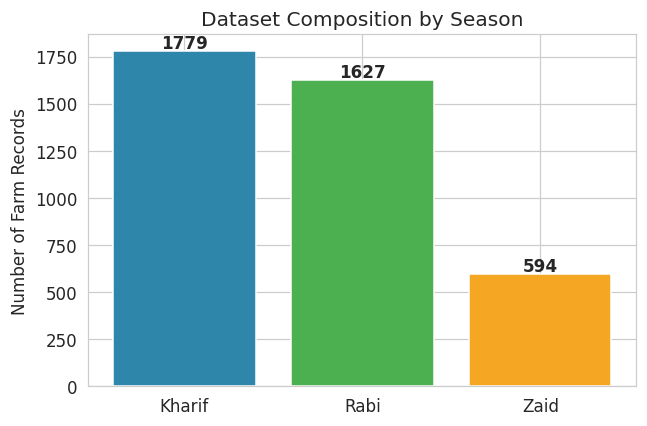

In [10]:
print(df_clean['Season'].value_counts().reindex(SEASON_ORDER))

fig, ax = plt.subplots(figsize=(6, 4))
cnt = df_clean['Season'].value_counts().reindex(SEASON_ORDER)
bars = ax.bar(cnt.index, cnt.values, color=[PALETTE[s] for s in SEASON_ORDER])
ax.set_ylabel('Number of Farm Records')
ax.set_title('Dataset Composition by Season')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f'{int(b.get_height())}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Kharif (monsoon-sown) accounts for the largest share of records (44%), followed by Rabi (41%) and Zaid (15%) — consistent with real-world Indian cropping patterns, where Zaid is a short, minor summer season squeezed between the two main seasons.

        Rainfall_mm  Avg_Temperature_C  Humidity_pct
Season                                              
Kharif        852.1               28.5          71.8
Rabi          435.9               23.5          57.9
Zaid          299.3               31.0          52.0


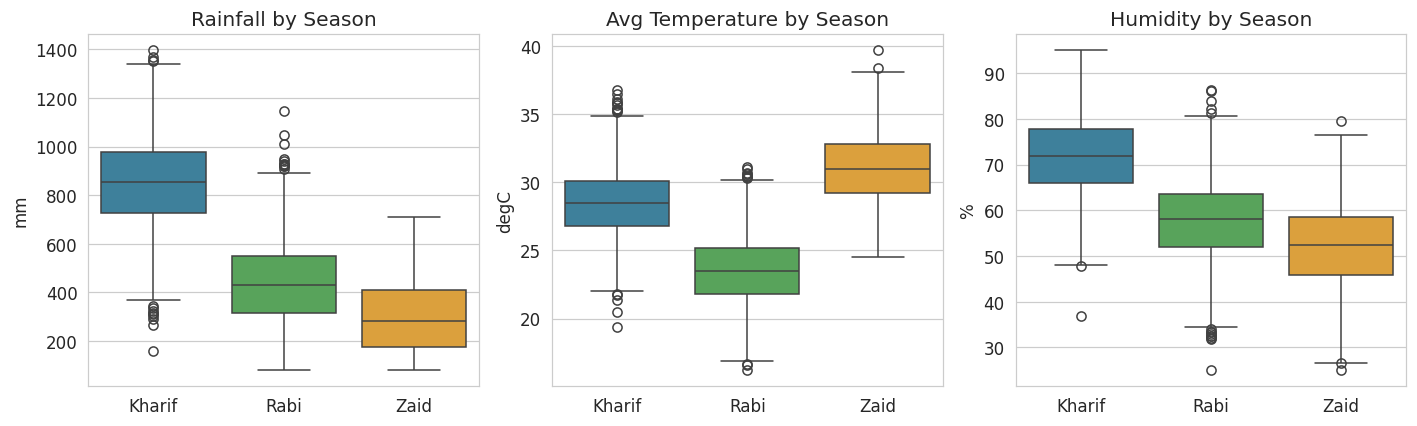

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title, unit in zip(axes, ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct'],
                                 ['Rainfall', 'Avg Temperature', 'Humidity'], ['mm', 'degC', '%']):
    sns.boxplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
                hue='Season', palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f'{title} by Season')
    ax.set_xlabel('')
    ax.set_ylabel(unit)
plt.tight_layout()
plt.show()

print(df_clean.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct']].mean().reindex(SEASON_ORDER).round(1))

**Observation:** Kharif is clearly the monsoon season — average rainfall (~852 mm) is roughly double Rabi (~436 mm) and nearly triple Zaid (~299 mm). Zaid is the hottest and driest season, which explains why it is typically farmed with assured irrigation rather than rainfall dependency.

## 6. Yield Analysis Across Seasons & Crops

In [12]:
# ANOVA: does Yield differ significantly by season (overall, across all crops)?
groups = [df_clean[df_clean['Season']==s]['Yield_Tonnes_Ha'] for s in SEASON_ORDER]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA on Yield_Tonnes_Ha across seasons: F={f_stat:.2f}, p={p_val:.4f}")
print("=> Not statistically significant at the whole-dataset level" if p_val >= 0.05 else "=> Statistically significant")
print("\nThis is expected: yield is driven far more by WHICH CROP is grown than by season alone,")
print("since crops differ by orders of magnitude (e.g. Sugarcane ~60-100 t/ha vs Wheat ~1-3 t/ha).")
print("The chart below therefore compares yield within each crop, across seasons.")

One-way ANOVA on Yield_Tonnes_Ha across seasons: F=1.46, p=0.2328
=> Not statistically significant at the whole-dataset level

This is expected: yield is driven far more by WHICH CROP is grown than by season alone,
since crops differ by orders of magnitude (e.g. Sugarcane ~60-100 t/ha vs Wheat ~1-3 t/ha).
The chart below therefore compares yield within each crop, across seasons.


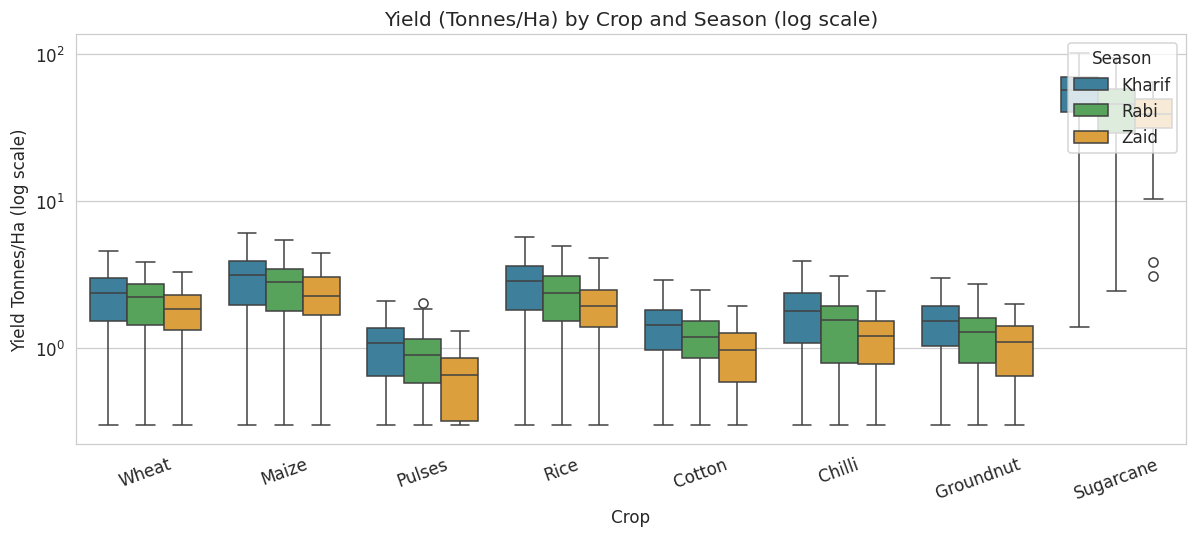

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_clean, x='Crop', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER,
            palette=PALETTE, ax=ax)
ax.set_yscale('log')
ax.set_title('Yield (Tonnes/Ha) by Crop and Season (log scale)')
ax.set_ylabel('Yield Tonnes/Ha (log scale)')
ax.legend(title='Season', loc='upper right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:** Within most crops, yield is fairly stable across seasons — differences of a few percent rather than multiples. This tells us seasonal variation shows up much more strongly in **cost, water use and profitability** than in raw yield per hectare (explored next).

## 7. Economic Performance Analysis (Cost, Revenue, Profit)

In [14]:
econ = df_clean.groupby('Season')[['Total_Cost_INR','Revenue_INR','Profit_INR','Profit_Margin_pct']]\
    .mean().reindex(SEASON_ORDER).round(0)
print(econ)

loss_pct = (df_clean.groupby('Season')['Loss_Making'].mean().reindex(SEASON_ORDER) * 100).round(1)
print("\n% of farms operating at a loss, by season:")
print(loss_pct)

        Total_Cost_INR  Revenue_INR  Profit_INR  Profit_Margin_pct
Season                                                            
Kharif        531804.0     710719.0    178915.0              -39.0
Rabi          513837.0     601526.0     87689.0              -44.0
Zaid          543977.0     519172.0    -24805.0              -69.0

% of farms operating at a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Loss_Making, dtype: float64


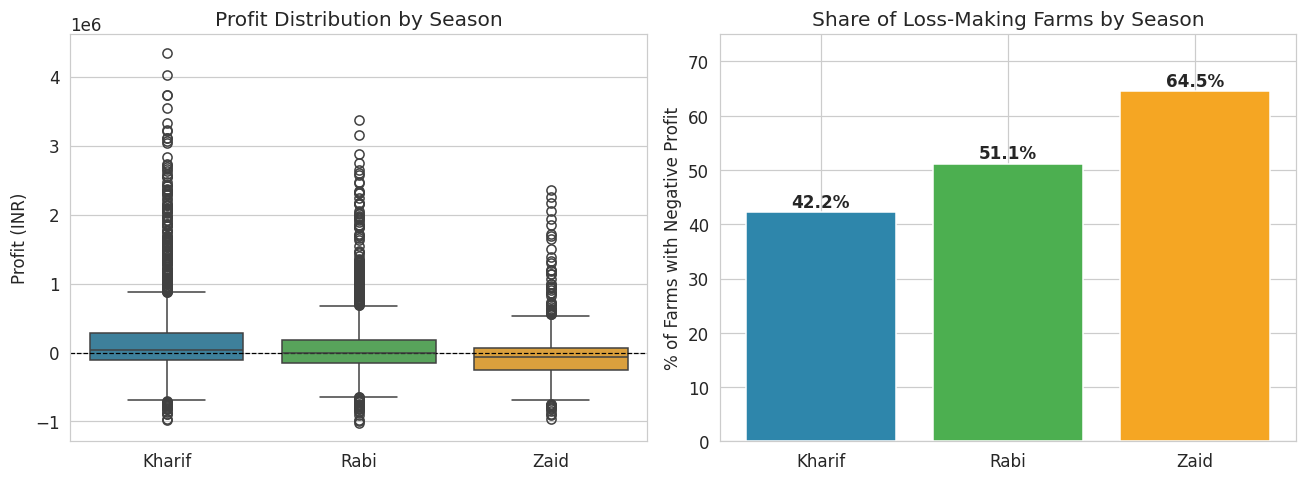

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=SEASON_ORDER,
            hue='Season', palette=PALETTE, legend=False, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Profit Distribution by Season')
axes[0].set_ylabel('Profit (INR)')
axes[0].set_xlabel('')

bars = axes[1].bar(loss_pct.index, loss_pct.values, color=[PALETTE[s] for s in SEASON_ORDER])
axes[1].set_title('Share of Loss-Making Farms by Season')
axes[1].set_ylabel('% of Farms with Negative Profit')
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontweight='bold')
axes[1].set_ylim(0, 75)
plt.tight_layout()
plt.show()

In [16]:
f_stat, p_val = stats.f_oneway(*[df_clean[df_clean['Season']==s]['Profit_INR'] for s in SEASON_ORDER])
print(f"One-way ANOVA on Profit_INR across seasons: F={f_stat:.2f}, p={p_val:.2e}")
print("=> Statistically significant difference in profit across seasons" if p_val < 0.05 else "=> Not significant")

One-way ANOVA on Profit_INR across seasons: F=34.29, p=1.71e-15
=> Statistically significant difference in profit across seasons


**Observation:** Profitability declines sharply and *significantly* (p < 0.001) from Kharif to Zaid. The share of loss-making farms **rises from 42% in Kharif to 51% in Rabi to 64.5% in Zaid** — meaning nearly two out of every three Zaid-season farms operate at a loss. Since yield itself doesn't fall nearly as much, this points to **rising input costs (especially water/irrigation) outweighing revenue** in the drier, hotter Zaid season.

## 8. Correlation Analysis

Top correlates of Yield_Tonnes_Ha:
Profit_INR          0.489350
Water_Used_m3       0.387373
Nitrogen_kg_ha      0.053633
Phosphorus_kg_ha    0.046685
Rainfall_mm         0.027051
Name: Yield_Tonnes_Ha, dtype: float64


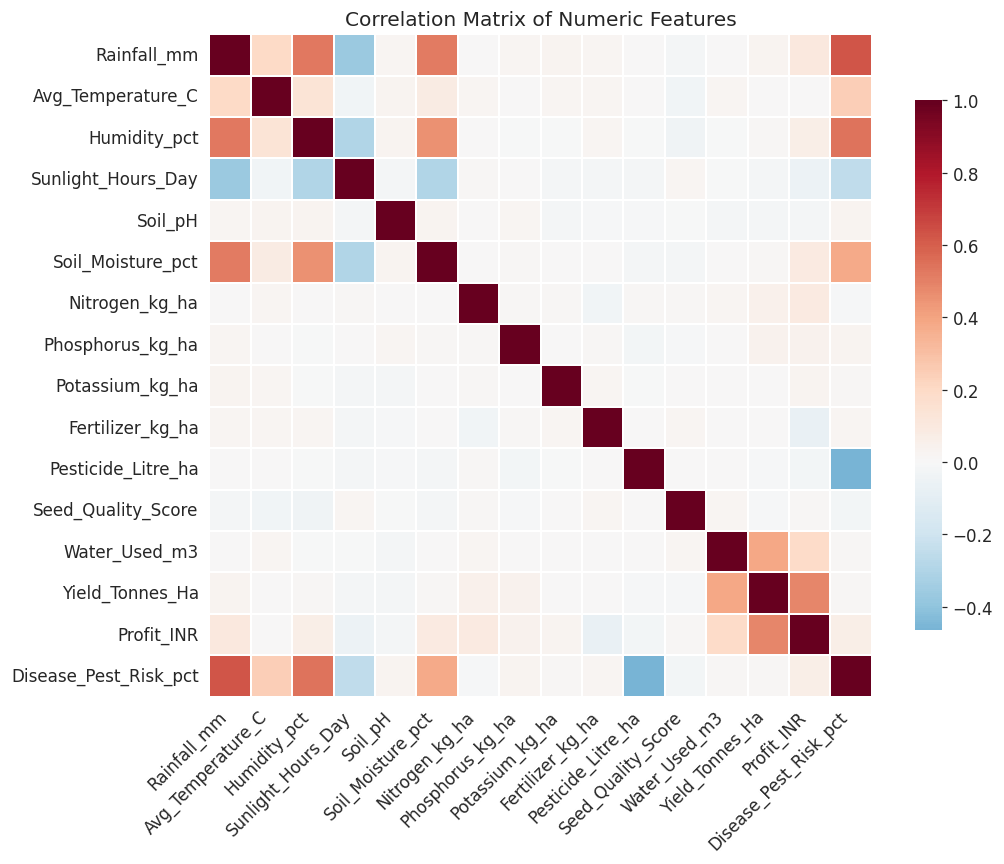

In [17]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Water_Used_m3',
            'Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top correlates of Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False).head(5))

**Observation:** Correlations among the environmental/input variables and yield are generally weak (the strongest, `Water_Used_m3`, is only ~0.39). This is a realistic and important finding, not a modeling failure — it tells us yield in this dataset is driven primarily by **which crop is grown**, with environmental and input factors playing a secondary, moderating role. This reinforces the crop-first, season-second lens used throughout this analysis.

## 9. Crop × Season Profitability Deep-Dive

Since yield differs mainly by crop, the most actionable seasonal question is: **which crop-season combinations are profitable, and which consistently lose money?**

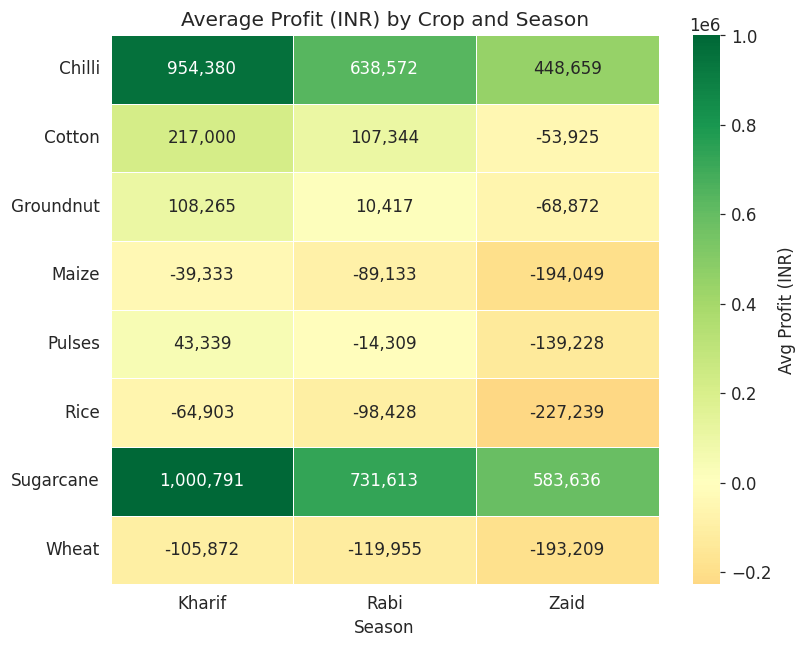

In [18]:
cs_profit = df_clean.groupby(['Crop','Season'])['Profit_INR'].mean().unstack().reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cs_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Avg Profit (INR)'})
ax.set_title('Average Profit (INR) by Crop and Season')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** 
- **Chilli and Sugarcane are profitable in every season**, and by a wide margin — Sugarcane averages ~₹10 lakh profit in Kharif alone.
- **Rice, Wheat, and Maize run at a loss in every single season**, with losses deepening in Zaid — these staple grain crops appear to be economically unviable under the input/output costs captured in this dataset, regardless of season.
- **Cotton, Groundnut, and Pulses are borderline** — profitable in Kharif/Rabi but tip into loss in Zaid.

This is the single most decision-relevant pattern in the dataset for crop-planning purposes.

## 10. Resource Usage & Water-Use Efficiency

Irrigation_Method   Drip  Flood  Rainfed  Sprinkler
Season                                             
Kharif             6.804  3.637    8.848      4.622
Rabi               6.047  3.478    6.873      4.644
Zaid               5.296  2.730    5.479      4.860


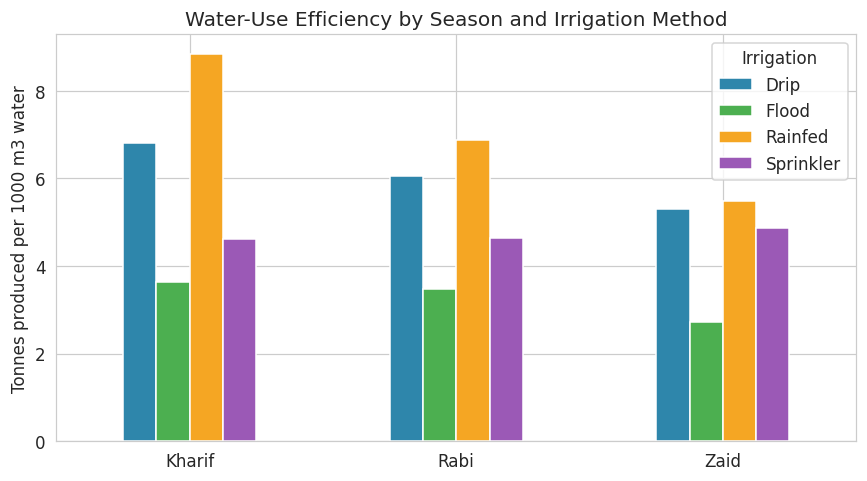

In [19]:
we = df_clean.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3']\
    .mean().unstack().reindex(SEASON_ORDER)
print(we.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
we.plot(kind='bar', ax=ax, color=['#2E86AB','#4CAF50','#F5A623','#9B59B6'])
ax.set_title('Water-Use Efficiency by Season and Irrigation Method')
ax.set_ylabel('Tonnes produced per 1000 m3 water')
ax.set_xlabel('')
plt.xticks(rotation=0)
ax.legend(title='Irrigation')
plt.tight_layout()
plt.show()

In [20]:
f_stat, p_val = stats.f_oneway(*[df_clean[df_clean['Season']==s]['Water_Efficiency_t_per_1000m3'] for s in SEASON_ORDER])
print(f"ANOVA on Water_Efficiency across seasons: F={f_stat:.2f}, p={p_val:.4f} -> {'significant' if p_val<0.05 else 'not significant'}")

ANOVA on Water_Efficiency across seasons: F=6.95, p=0.0010 -> significant


**Observation:** Water-use efficiency is significantly lower in Zaid than in Kharif for every irrigation method — **Rainfed and Drip are consistently the most water-efficient methods across all seasons**, while **Flood irrigation is the least efficient, by more than 2x**. Given Zaid's higher heat and lower rainfall, Flood irrigation in that season is a clear inefficiency worth targeting.

## 11. Disease & Pest Risk Patterns

Season
Kharif    54.5
Rabi      40.5
Zaid      38.2
Name: Disease_Pest_Risk_pct, dtype: float64

ANOVA: F=1049.47, p=0.00e+00 -> significant


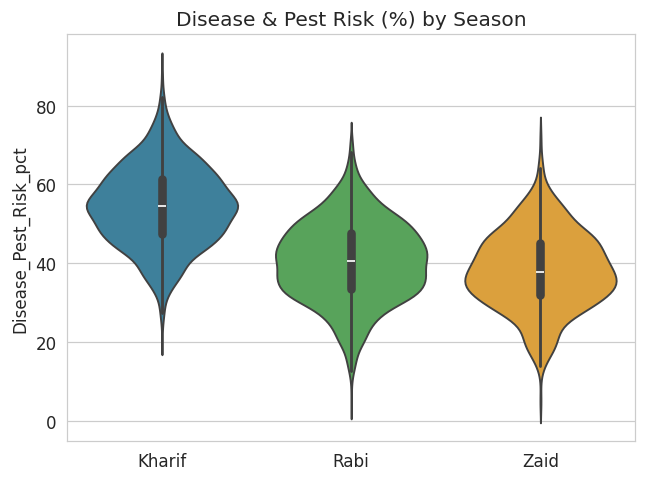

In [21]:
risk = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER)
print(risk.round(1))

f_stat, p_val = stats.f_oneway(*[df_clean[df_clean['Season']==s]['Disease_Pest_Risk_pct'] for s in SEASON_ORDER])
print(f"\nANOVA: F={f_stat:.2f}, p={p_val:.2e} -> {'significant' if p_val<0.05 else 'not significant'}")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.violinplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
                hue='Season', palette=PALETTE, legend=False, ax=ax)
ax.set_title('Disease & Pest Risk (%) by Season')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Observation:** Disease and pest risk is significantly highest in **Kharif (~54%)**, the humid monsoon season, and lowest in **Zaid (~38%)** — the warm, humid conditions that make Kharif good for rainfall also make it favorable for pest and disease pressure. This is a classic agronomic trade-off: the wettest season needs the most vigilant pest management.

## 12. State-wise Seasonal Performance

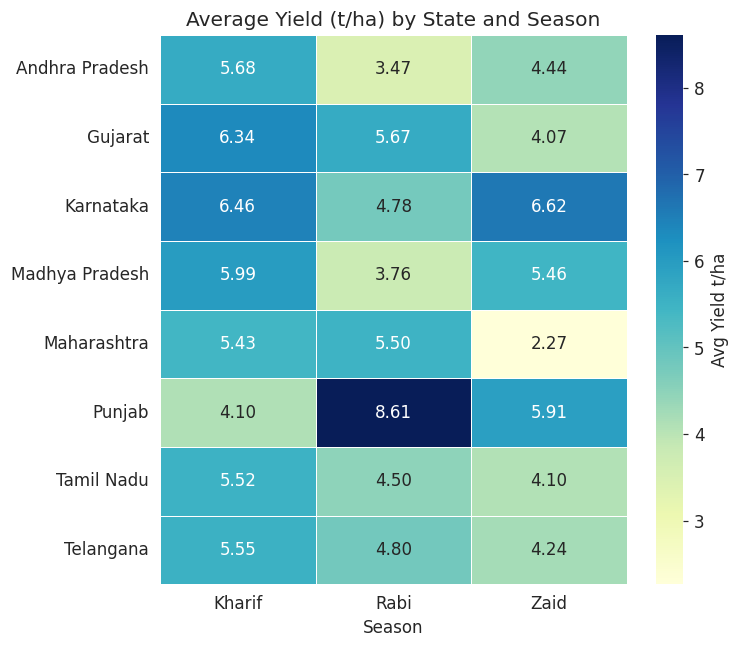

In [22]:
st_yield = df_clean.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack().reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(st_yield, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Avg Yield t/ha'})
ax.set_title('Average Yield (t/ha) by State and Season')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** Seasonal patterns are **not uniform across states**. Punjab stands out with its best yield in Rabi (8.6 t/ha, well above every other state/season cell), reflecting its wheat-dominant Rabi belt, while most other states peak in Kharif. This means a one-size-fits-all seasonal recommendation would be misleading — seasonal strategy should be regionalized.

## 13. Key Insights

1. **Profitability falls sharply from Kharif -> Rabi -> Zaid**, with loss-making farms rising from 42% to 51% to 64.5% — a statistically significant trend (p < 0.001) — even though yield itself is relatively stable across seasons.
2. **Crop choice matters far more than season**: Chilli and Sugarcane are profitable in every season; Rice, Wheat, and Maize are loss-making in every season. Season shifts the *degree* of profit/loss, not the fundamental winner/loser pattern.
3. **Kharif is the monsoon season** (~852mm rainfall, 2x Rabi and 3x Zaid) but also carries the **highest disease/pest risk (~54%)** — the classic rainfall-vs-pest-pressure trade-off.
4. **Water-use efficiency drops significantly in Zaid**, and **Flood irrigation is the least efficient method in every season** (roughly half the efficiency of Drip/Rainfed) — a major lever for cutting costs in the driest season.
5. **Environmental/input variables correlate weakly with yield** (strongest is Water_Used_m3 at ~0.39) — yield is overwhelmingly crop-driven, meaning generic agronomic advice must be crop-specific to be useful.
6. **Seasonal performance is not uniform across states** — e.g., Punjab peaks in Rabi while most other states peak in Kharif — so recommendations should be regionalized rather than applied nationally.


## 14. Recommendations

- **Re-evaluate Zaid-season cultivation of Rice, Wheat, and Maize** — these combinations show the deepest losses; consider shifting to Chilli/Sugarcane where feasible, or provide targeted subsidies/support if food-security staples must continue.
- **Prioritize Drip or Rainfed irrigation over Flood irrigation**, especially in Zaid, to improve water-use efficiency and cut input costs during the least profitable season.
- **Strengthen pest/disease surveillance specifically in Kharif**, when risk peaks alongside rainfall — early monitoring and preventive treatment could reduce yield/quality losses without waiting for outbreaks.
- **Regionalize seasonal crop-calendars** rather than applying one national seasonal recommendation — e.g., Punjab's Rabi wheat strength should inform state-specific planning distinct from the general Kharif-peak pattern.
- **Investigate cost structures behind the Rice/Wheat/Maize losses** (e.g., fertilizer, pesticide, market price realization) in follow-up analysis, since yield alone does not explain their unprofitability.


## 15. Conclusion

This analysis set out to investigate how agricultural performance varies across seasons, using a 4,000-record dataset spanning three cropping seasons, eight states, and eight crops. After cleaning a small number of missing values and validating apparent outliers as legitimate crop-specific yields, the analysis shows that **season most strongly affects the economics of farming (cost, water efficiency, disease/pest risk, and profitability) rather than raw per-hectare yield, which is instead driven primarily by crop choice**. Kharif is the wettest and highest-pest-risk season; Zaid is the driest, least water-efficient, and least profitable, with nearly two-thirds of Zaid farms operating at a loss. These findings support evidence-based, crop- and region-specific seasonal planning rather than a single blanket seasonal strategy, and provide a solid foundation for further modeling (e.g., predicting profit or yield) in future work.
